In [1]:
import rubin_sim
from rubin_sim import maf
from os.path import splitext, basename

import numpy as np
import healpy as hp
import pylab as pl

/global/homes/q/qhang/.conda/envs/rubin_new/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def get_maf_maps(opsim_db, metric, constraint, summary_stats, data_dir, info_label=None):
    
    bundle = maf.MetricBundle(
        metric,
        slicer,
        constraint=constraint,
        run_name=run_name,
        summary_metrics=summary_stats,
        info_label =info_label,
    )
    bg = maf.MetricBundleGroup(
        [bundle], 
        opsim_db, 
        out_dir=data_dir,
    )
    bg.run_all()
    
    
def load_maf_map(fname):
    
    fin = maf.MetricBundle.load(fname)
    #counts/map values
    opmap=fin.metric_values
    mafmap=np.copy(opmap.data)
    mafmap[opmap.mask]=np.nan
    
    return mafmap


def maf_maps_to_fits(fname_in):
    usemap = load_maf_map(fname_in)
    # save this into fits file:
    fname = fname_in[:-3] + 'fits'
    hp.write_map(fname, usemap,overwrite=True)
    print("Written: %s"%fname)

# Baseline 5.3

In [3]:
# Get Opsim_file name
#opsim_fname = rubin_sim.data.get_baseline()
#print(opsim_fname)
opsim_fname="/pscratch/sd/q/qhang/rubin_baseline_db/baseline_v5.3.0_10yrs.db"
# load database
#opsim_db = maf.db.OpsimDatabase(opsim_fname)
# Set run_name
run_name = splitext(basename(opsim_fname))[0]
print("Run name: ", run_name)

Run name:  baseline_v5.3.0_10yrs


In [4]:
# Set slicer to healpix with nside=128
slicer =  maf.slicers.HealpixSlicer(nside=128)
# Summary stats 
#summarystats = maf.standardSummary()
summarystats = maf.batches.standard_summary
print(summarystats)

# Set the sim data dir
import os 
os.environ["RUBIN_SIM_DATA_DIR"]="/pscratch/sd/q/qhang/rubin_sim_data/"
print(os.getenv("RUBIN_SIM_DATA_DIR"))

Healpix slicer using NSIDE=128, approximate resolution 27.483891 arcminutes
<function standard_summary at 0x7fbba3de7420>
/pscratch/sd/q/qhang/rubin_sim_data/


In [11]:
# Set data_dir where outputs are saved
data_dir = "/pscratch/sd/q/qhang/rubin_baseline_v5.3/"
savedir=data_dir
band_list=['u','g','r','i','z','y']

# grab the map

ExgalM5

In [6]:
summary_stats = None
#metric = maf.ExgalM5WithCuts(filter_col='band')
metric = maf.ExgalM5()
for band in "ugrizy":
    print(f"working on {band}")
    for Yobs in [1,4]:
        nights=int(Yobs*365)
        constraint = f"band = '{band}' and night <= {nights} "
        constraint += "and scheduler_note not like 'DD%' and scheduler_note not like '%twilight%' and scheduler_note not like 'ToO%'"
        get_maf_maps(opsim_fname, metric, constraint, summary_stats, savedir+"wfd/", 
                     info_label=f"{band}-band-{Yobs}-year-wfd")

working on u


/global/homes/q/qhang/.conda/envs/rubin_new/lib/python3.11/site-packages/rubin_sim/maf/slicers/base_spatial_slicer.py:122: UserWarning: Warning:  Loading maps but cache on.Should probably set use_cache=False in slicer.
  warnings.warn(


working on g
working on r
working on i
working on z
working on y


In [12]:
for band in "ugrizy":
    for Yobs in [1,4]:
        nights=int(Yobs*365)
        fname = savedir + f"/wfd/baseline_v5_3_0_10yrs_ExgalM5_{band}-band-{Yobs}-year-wfd_HEAL.npz"
        maf_maps_to_fits(fname)

setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]


Healpix slicer using NSIDE=128, approximate resolution 27.483891 arcminutes
Written: /pscratch/sd/q/qhang/rubin_baseline_v5.3//wfd/baseline_v5_3_0_10yrs_ExgalM5_u-band-1-year-wfd_HEAL.fits
Healpix slicer using NSIDE=128, approximate resolution 27.483891 arcminutes
Written: /pscratch/sd/q/qhang/rubin_baseline_v5.3//wfd/baseline_v5_3_0_10yrs_ExgalM5_u-band-4-year-wfd_HEAL.fits


setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]


Healpix slicer using NSIDE=128, approximate resolution 27.483891 arcminutes
Written: /pscratch/sd/q/qhang/rubin_baseline_v5.3//wfd/baseline_v5_3_0_10yrs_ExgalM5_g-band-1-year-wfd_HEAL.fits
Healpix slicer using NSIDE=128, approximate resolution 27.483891 arcminutes
Written: /pscratch/sd/q/qhang/rubin_baseline_v5.3//wfd/baseline_v5_3_0_10yrs_ExgalM5_g-band-4-year-wfd_HEAL.fits


setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]


...

Healpix slicer using NSIDE=128, approximate resolution 27.483891 arcminutes
Written: /pscratch/sd/q/qhang/rubin_baseline_v5.3//wfd/baseline_v5_3_0_10yrs_ExgalM5_i-band-1-year-wfd_HEAL.fits
Healpix slicer using NSIDE=128, approximate resolution 27.483891 arcminutes
Written: /pscratch/sd/q/qhang/rubin_baseline_v5.3//wfd/baseline_v5_3_0_10yrs_ExgalM5_i-band-4-year-wfd_HEAL.fits
Healpix slicer using NSIDE=128, approximate resolution 27.483891 arcminutes


setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]


Written: /pscratch/sd/q/qhang/rubin_baseline_v5.3//wfd/baseline_v5_3_0_10yrs_ExgalM5_z-band-1-year-wfd_HEAL.fits
Healpix slicer using NSIDE=128, approximate resolution 27.483891 arcminutes
Written: /pscratch/sd/q/qhang/rubin_baseline_v5.3//wfd/baseline_v5_3_0_10yrs_ExgalM5_z-band-4-year-wfd_HEAL.fits
Healpix slicer using NSIDE=128, approximate resolution 27.483891 arcminutes
Written: /pscratch/sd/q/qhang/rubin_baseline_v5.3//wfd/baseline_v5_3_0_10yrs_ExgalM5_y-band-1-year-wfd_HEAL.fits


setting the output map dtype to [dtype('float64')]


Healpix slicer using NSIDE=128, approximate resolution 27.483891 arcminutes
Written: /pscratch/sd/q/qhang/rubin_baseline_v5.3//wfd/baseline_v5_3_0_10yrs_ExgalM5_y-band-4-year-wfd_HEAL.fits


# DESI

In [7]:
# Get Opsim_file name
#opsim_fname = rubin_sim.data.get_baseline()
#print(opsim_fname)
opsim_fname="/pscratch/sd/q/qhang/rubin_baseline_db/desi_3040_v5.3.0_10yrs.db"
# load database
#opsim_db = maf.db.OpsimDatabase(opsim_fname)
# Set run_name
run_name = splitext(basename(opsim_fname))[0]
print("Run name: ", run_name)

Run name:  desi_3040_v5.3.0_10yrs


In [13]:
# Set data_dir where outputs are saved
data_dir = "/pscratch/sd/q/qhang/rubin_baseline_v5.3_desi/"
savedir=data_dir
band_list=['u','g','r','i','z','y']

In [9]:
summary_stats = None
#metric = maf.ExgalM5WithCuts(filter_col='band')
metric = maf.ExgalM5()
for band in "ugrizy":
    print(f"working on {band}")
    for Yobs in [1,4]:
        nights=int(Yobs*365)
        constraint = f"band = '{band}' and night <= {nights} "
        constraint += "and scheduler_note not like 'DD%' and scheduler_note not like '%twilight%' and scheduler_note not like 'ToO%'"
        get_maf_maps(opsim_fname, metric, constraint, summary_stats, savedir+"wfd/", 
                     info_label=f"{band}-band-{Yobs}-year-wfd")

working on u


/global/homes/q/qhang/.conda/envs/rubin_new/lib/python3.11/site-packages/rubin_sim/maf/slicers/base_spatial_slicer.py:122: UserWarning: Warning:  Loading maps but cache on.Should probably set use_cache=False in slicer.
  warnings.warn(


working on g
working on r
working on i
working on z
working on y


In [14]:
for band in "ugrizy":
    for Yobs in [1,4]:
        nights=int(Yobs*365)
        fname = savedir + f"/wfd/desi_3040_v5_3_0_10yrs_ExgalM5_{band}-band-{Yobs}-year-wfd_HEAL.npz"
        maf_maps_to_fits(fname)

setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]


Healpix slicer using NSIDE=128, approximate resolution 27.483891 arcminutes
Written: /pscratch/sd/q/qhang/rubin_baseline_v5.3_desi//wfd/desi_3040_v5_3_0_10yrs_ExgalM5_u-band-1-year-wfd_HEAL.fits
Healpix slicer using NSIDE=128, approximate resolution 27.483891 arcminutes


setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]


Written: /pscratch/sd/q/qhang/rubin_baseline_v5.3_desi//wfd/desi_3040_v5_3_0_10yrs_ExgalM5_u-band-4-year-wfd_HEAL.fits
Healpix slicer using NSIDE=128, approximate resolution 27.483891 arcminutes
Written: /pscratch/sd/q/qhang/rubin_baseline_v5.3_desi//wfd/desi_3040_v5_3_0_10yrs_ExgalM5_g-band-1-year-wfd_HEAL.fits
Healpix slicer using NSIDE=128, approximate resolution 27.483891 arcminutes


setting the output map dtype to [dtype('float64')]


...

Written: /pscratch/sd/q/qhang/rubin_baseline_v5.3_desi//wfd/desi_3040_v5_3_0_10yrs_ExgalM5_r-band-4-year-wfd_HEAL.fits
Healpix slicer using NSIDE=128, approximate resolution 27.483891 arcminutes
Written: /pscratch/sd/q/qhang/rubin_baseline_v5.3_desi//wfd/desi_3040_v5_3_0_10yrs_ExgalM5_i-band-1-year-wfd_HEAL.fits
Healpix slicer using NSIDE=128, approximate resolution 27.483891 arcminutes
Written: /pscratch/sd/q/qhang/rubin_baseline_v5.3_desi//wfd/desi_3040_v5_3_0_10yrs_ExgalM5_i-band-4-year-wfd_HEAL.fits


setting the output map dtype to [dtype('float64')]


Healpix slicer using NSIDE=128, approximate resolution 27.483891 arcminutes
Written: /pscratch/sd/q/qhang/rubin_baseline_v5.3_desi//wfd/desi_3040_v5_3_0_10yrs_ExgalM5_z-band-1-year-wfd_HEAL.fits
Healpix slicer using NSIDE=128, approximate resolution 27.483891 arcminutes


setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]


Written: /pscratch/sd/q/qhang/rubin_baseline_v5.3_desi//wfd/desi_3040_v5_3_0_10yrs_ExgalM5_z-band-4-year-wfd_HEAL.fits
Healpix slicer using NSIDE=128, approximate resolution 27.483891 arcminutes
Written: /pscratch/sd/q/qhang/rubin_baseline_v5.3_desi//wfd/desi_3040_v5_3_0_10yrs_ExgalM5_y-band-1-year-wfd_HEAL.fits
Healpix slicer using NSIDE=128, approximate resolution 27.483891 arcminutes
Written: /pscratch/sd/q/qhang/rubin_baseline_v5.3_desi//wfd/desi_3040_v5_3_0_10yrs_ExgalM5_y-band-4-year-wfd_HEAL.fits


# Postprocess maps:

In [20]:
basedir1 = "/pscratch/sd/q/qhang/rubin_baseline_v5.3_desi/wfd/"
basedir2 = "/pscratch/sd/q/qhang/rubin_baseline_v5.3/wfd/"

In [26]:
# load mask
mask = hp.read_map("/global/cfs/cdirs/lsst/groups/PZ/users/qhang/baseline_v5.1_maps/masks/WFD-mask-nside-128.fits")

In [16]:
def list_files_in_directory(directory_path):
    files_list = []
    for entry in os.listdir(directory_path):
        full_path = os.path.join(directory_path, entry)
        if os.path.isdir(full_path)!= True:
            files_list.append(full_path)
    return files_list

In [22]:
# load maps:
baseline={}
desi={}

for Yobs in [1,4]:
    baseline[Yobs] = {}
    desi[Yobs] = {}
    for band in "ugrizy":
        baseline[Yobs][band] = hp.read_map(basedir2 + f"baseline_v5_3_0_10yrs_ExgalM5_{band}-band-{Yobs}-year-wfd_HEAL.fits")
        desi[Yobs][band] = hp.read_map(basedir1 + f"desi_3040_v5_3_0_10yrs_ExgalM5_{band}-band-{Yobs}-year-wfd_HEAL.fits")

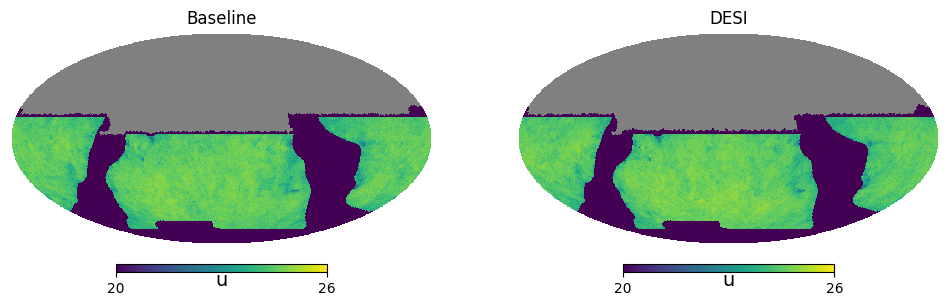

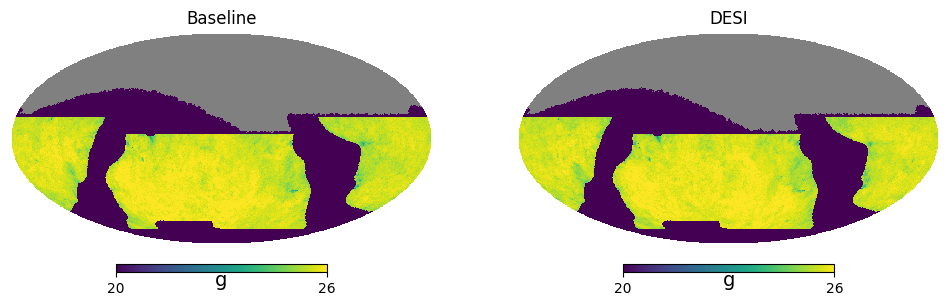

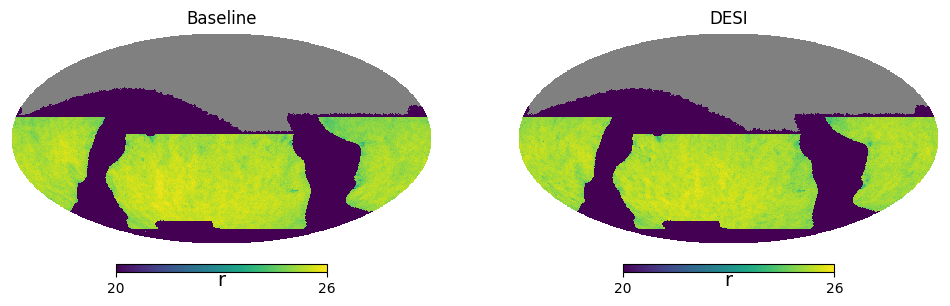

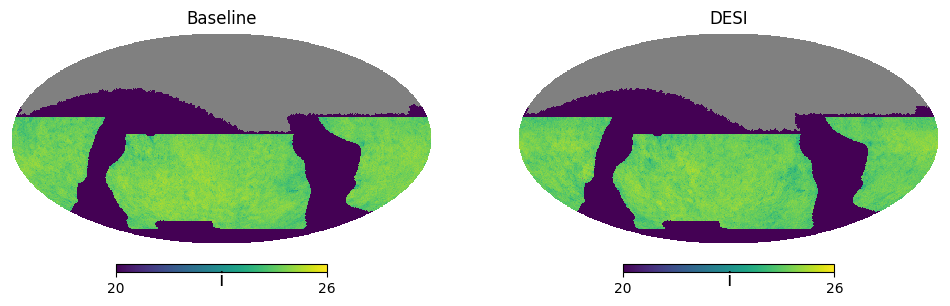

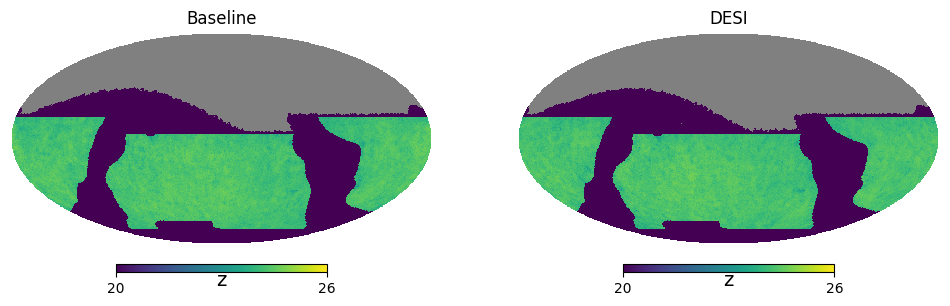

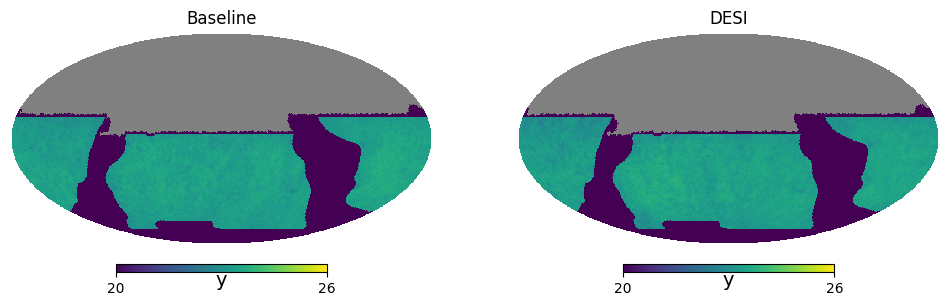

In [30]:
Yobs = 1
for i, band in enumerate("ugrizy"):
    fig,axarr=pl.subplots(1,2,figsize=[12,5])
    pl.sca(axarr[0])
    hp.mollview(baseline[Yobs][band]*mask, hold=True, min=20, max=26, title="Baseline", unit=band)
    pl.sca(axarr[1])
    hp.mollview(desi[Yobs][band]*mask, hold=True, min=20, max=26, title="DESI", unit=band)

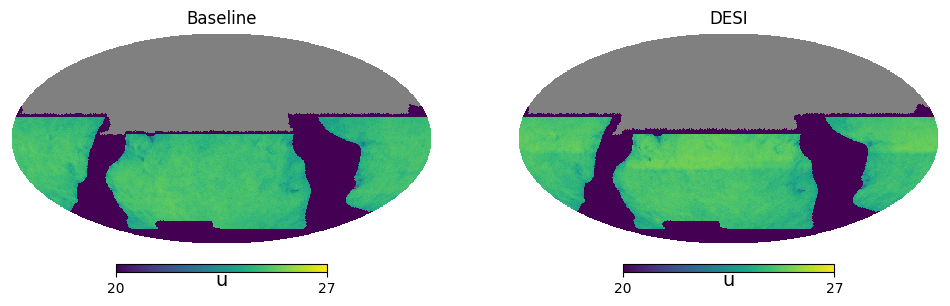

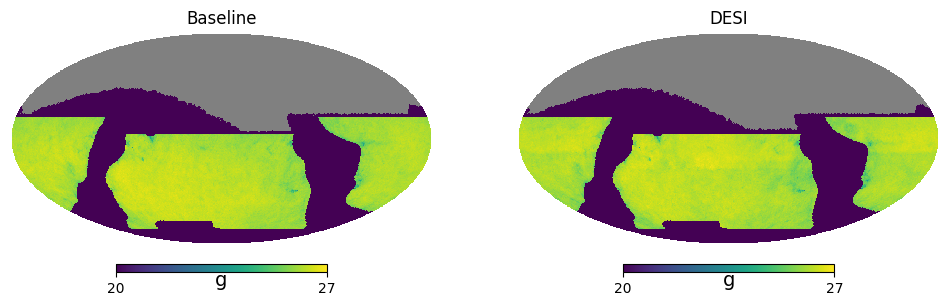

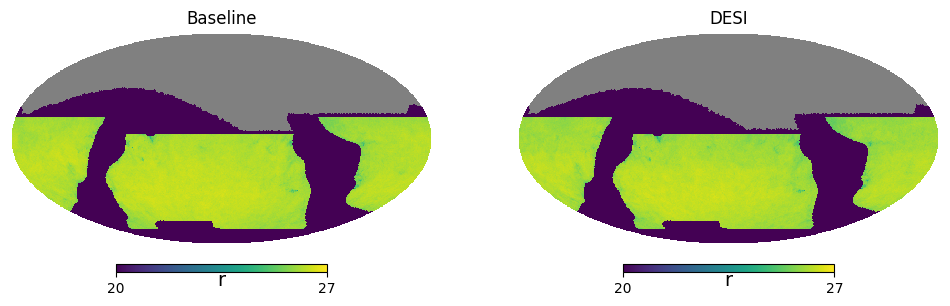

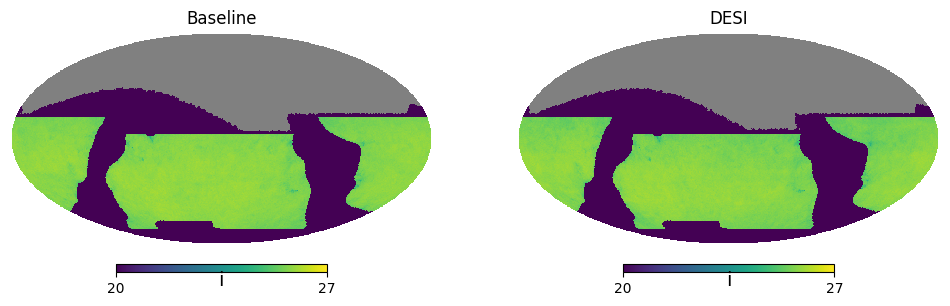

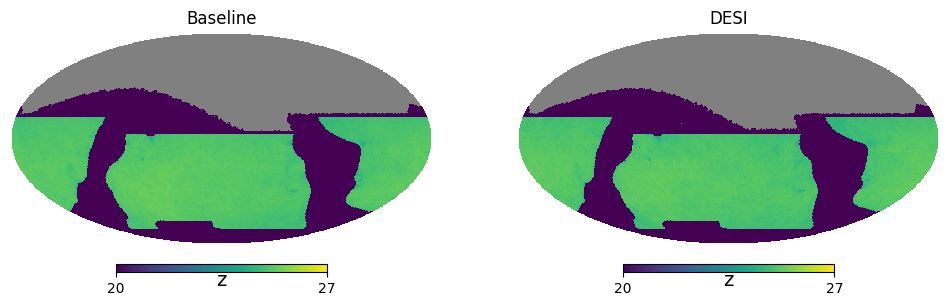

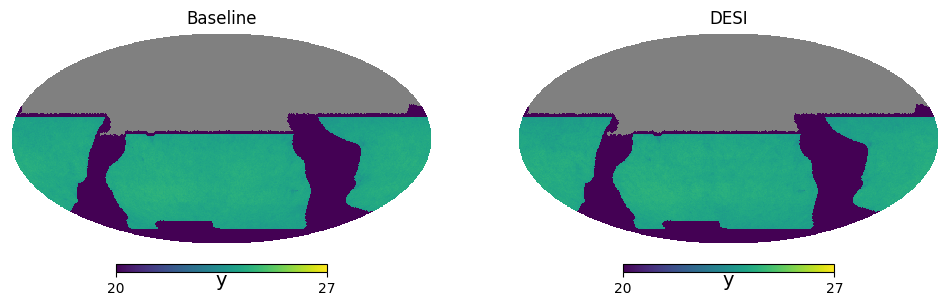

In [32]:
Yobs = 4
for i, band in enumerate("ugrizy"):
    fig,axarr=pl.subplots(1,2,figsize=[12,5])
    pl.sca(axarr[0])
    hp.mollview(baseline[Yobs][band]*mask, hold=True, min=20, max=27, title="Baseline", unit=band)
    pl.sca(axarr[1])
    hp.mollview(desi[Yobs][band]*mask, hold=True, min=20, max=27, title="DESI", unit=band)

Text(0.5, 1.0, 'OpSim 5.3 WFD')

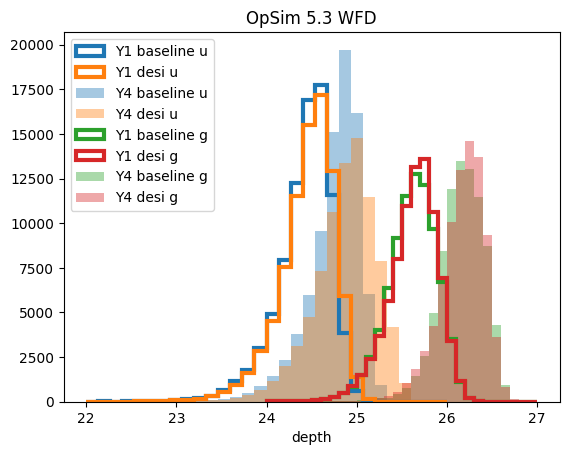

In [58]:
# histogram:

cc = pl.hist(baseline[1]['u'][mask.astype(bool)], bins=30, range=[22,26], histtype='step',lw=3,label="Y1 baseline u")
cc = pl.hist(desi[1]['u'][mask.astype(bool)], bins=30, range=[22,26], histtype='step',lw=3,label="Y1 desi u")

cc = pl.hist(baseline[4]['u'][mask.astype(bool)], bins=30, range=[22,26], alpha=0.4, color='C0',label="Y4 baseline u")
cc = pl.hist(desi[4]['u'][mask.astype(bool)], bins=30, range=[22,26], alpha=0.4,color='C1',label="Y4 desi u")

# histogram:

cc = pl.hist(baseline[1]['g'][mask.astype(bool)], bins=30, range=[24,27], histtype='step',lw=3, color='C2',label="Y1 baseline g")
cc = pl.hist(desi[1]['g'][mask.astype(bool)], bins=30, range=[24,27], histtype='step',lw=3, color='C3',label="Y1 desi g")

cc = pl.hist(baseline[4]['g'][mask.astype(bool)], bins=30, range=[24,27], alpha=0.4, color='C2',label="Y4 baseline g")
cc = pl.hist(desi[4]['g'][mask.astype(bool)], bins=30, range=[24,27], alpha=0.4,color='C3',label="Y4 desi g")

pl.legend()
pl.xlabel("depth")
pl.title("OpSim 5.3 WFD")

Text(0.5, 1.0, 'OpSim 5.3 WFD Y4 only')

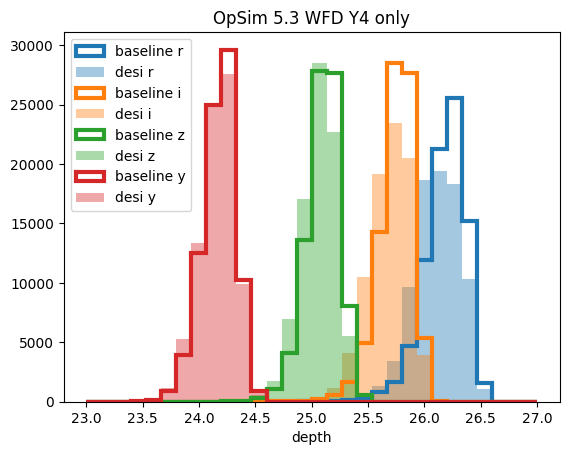

In [100]:
# histogram:

#cc = pl.hist(baseline[1]['u'][mask.astype(bool)], bins=30, range=[22,26], histtype='step',lw=3,label="Y1 baseline u")
#cc = pl.hist(desi[1]['u'][mask.astype(bool)], bins=30, range=[22,26], histtype='step',lw=3,label="Y1 desi u")

for i, band in enumerate("rizy"):
    cc = pl.hist(baseline[4][band][mask.astype(bool)], bins=30, range=[23,27], histtype='step',lw=3,
                 color=f'C{i}',label=f"baseline {band}")
    cc = pl.hist(desi[4][band][mask.astype(bool)], bins=30, range=[23,27], alpha=0.4,
                 color=f'C{i}',label=f"desi {band}")
# histogram:

#cc = pl.hist(baseline[1]['g'][mask.astype(bool)], bins=30, range=[24,27], histtype='step',lw=3, color='C2',label="Y1 baseline g")
#cc = pl.hist(desi[1]['g'][mask.astype(bool)], bins=30, range=[24,27], histtype='step',lw=3, color='C3',label="Y1 desi g")

#cc = pl.hist(baseline[4]['g'][mask.astype(bool)], bins=30, range=[24,27], alpha=0.4, color='C2',label="Y4 baseline g")
#cc = pl.hist(desi[4]['g'][mask.astype(bool)], bins=30, range=[24,27], alpha=0.4,color='C3',label="Y4 desi g")

pl.legend()
pl.xlabel("depth")
pl.title("OpSim 5.3 WFD Y4 only")

In [102]:
for band in "ugrizy":
    use = baseline[4][band][mask.astype(bool)]
    use = use[~np.isnan(use)]
    print(band, round(np.median(use),2))

u 24.81
g 26.18
r 26.2
i 25.77
z 25.11
y 24.2


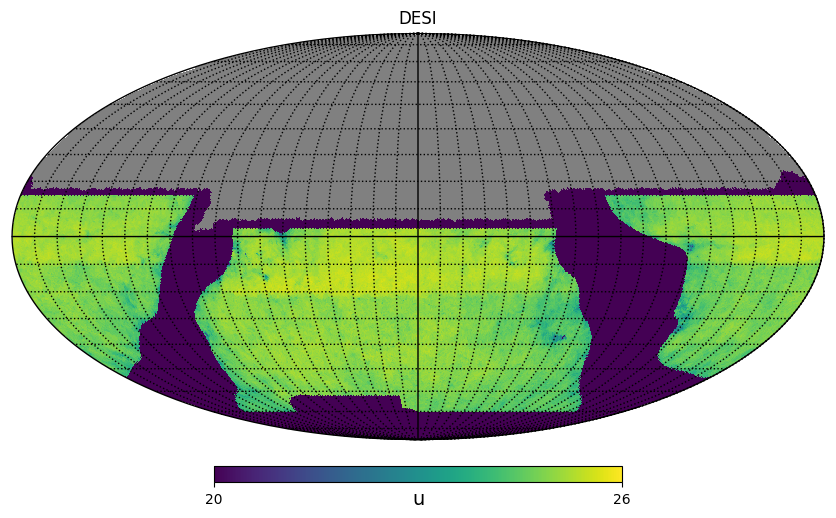

In [65]:
Yobs=4
band='u'
hp.mollview(desi[Yobs][band]*mask, min=20, max=26, title="DESI", unit=band)
hp.graticule(dpar=10)

u 24.46 24.53
g 25.59 25.71
u 25.11 24.79
g 26.29 26.14


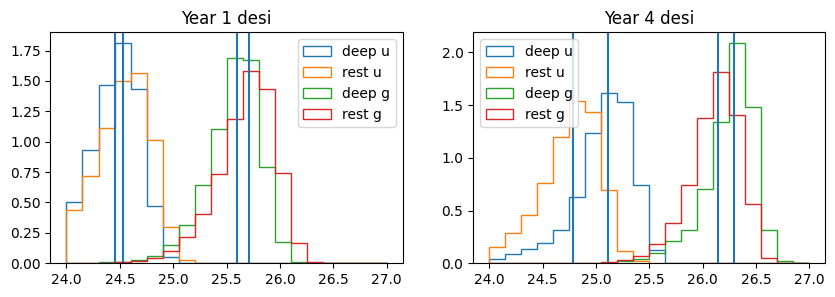

In [91]:
# apply cut and look at medium:
ipix = np.arange(int(12*128**2))
ra, dec = hp.pix2ang(128, ipix, lonlat=True)
select_pix = ((ra < 100)| (ra > 280))&(dec > -20) 
select_pix2 = (ra >= 100) & (ra <= 280) * (dec >-10)
select_pix = select_pix + select_pix2
#hp.mollview(select_pix*desi[Yobs][band]*mask)
fig,axarr=pl.subplots(1,2,figsize=[10,3])

for i, Yobs in enumerate([1,4]):
    pl.sca(axarr[i])
    pl.title(f'Year {Yobs} desi')
    for band in 'ug':
        deep = desi[Yobs][band][(mask*select_pix).astype(bool)]
        rest = desi[Yobs][band][(mask*(~select_pix)).astype(bool)]
        cc = pl.hist(deep, bins=20, range=[24,27], histtype='step', density=True, label=f'deep {band}')
        cc = pl.hist(rest, bins=20, range=[24,27], histtype='step', density=True, label=f'rest {band}')
        print(band, round(np.median(deep),2), round(np.median(rest),2))
        pl.axvline(np.median(deep))
        pl.axvline(np.median(rest))
    pl.legend()

r 25.27
i 24.65
z 24.25
y 23.39
r 26.12
i 25.7
z 25.07
y 24.19


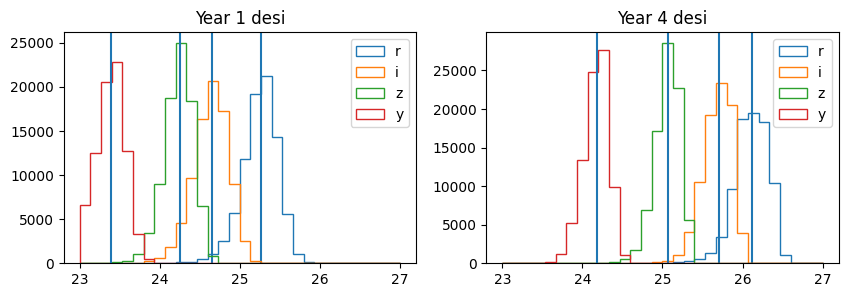

In [97]:
# get median in all other bands
fig,axarr=pl.subplots(1,2,figsize=[10,3])

for i, Yobs in enumerate([1,4]):
    pl.sca(axarr[i])
    pl.title(f'Year {Yobs} desi')
    for band in 'rizy':
        pl.hist(desi[Yobs][band][mask.astype(bool)], bins=30, range=[23,27], histtype='step', label=band)
        use = desi[Yobs][band][mask.astype(bool)]
        use = use[~np.isnan(use)]
        pl.axvline(np.median(use))
        print(band, round(np.median(use),2))
    pl.legend()